In [4]:
!pip install pandas
!pip install matplotlib
!pip install scikit-learn


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


[notice] A new release of pip is available: 23.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl (41.3 MB)
  Using cached joblib-1.5.3-py3-none-any.whl (309 kB)



[notice] A new release of pip is available: 23.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
df = pd.read_csv("clean_dataset.csv")
print(df.columns)
df.head()

Index(['date', 'steps', 'calories_burned', 'distance_km', 'active_minutes',
       'sleep_hours', 'heart_rate_avg', 'workout_type', 'weather_conditions',
       'location', 'mood'],
      dtype='object')


,date,steps,calories_burned,distance_km,active_minutes,sleep_hours,heart_rate_avg,workout_type,weather_conditions,location,mood
0,2023-01-01,4530,2543.02,16.10,613,1.5,176,Walking,Clear,Park,Tired
1,2023-01-01,11613,1720.76,8.10,352,6.3,128,Cycling,Fog,Park,Happy
2,2023-01-01,27335,1706.35,3.57,236,6.7,134,Yoga,Snow,Park,Neutral
3,2023-01-01,13459,2912.38,6.41,1329,11.6,116,Swimming,Rain,Office,Tired
4,2023-01-01,15378,3344.51,17.88,52,7.4,84,Swimming,Rain,Office,Neutral


In [19]:
X = df[['steps', 'sleep_hours', 'heart_rate_avg']]

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

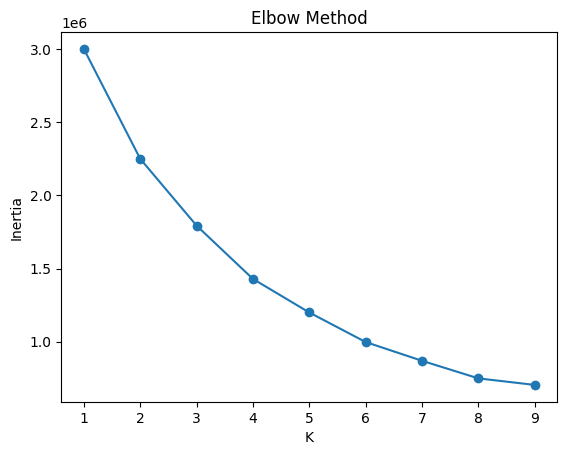

In [21]:
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("K") 
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [25]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled) 

In [26]:
!pip install seaborn


[notice] A new release of pip is available: 23.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
cluster_names = {
    0: 'Low Activity',
    1: 'High Activity',
    2: 'Moderate Activity'
}
df['Cluster_Label'] = df['Cluster'].map(cluster_names)

In [28]:
df[['Cluster', 'Cluster_Label']].head()

,Cluster,Cluster_Label
0,2,Moderate Activity
1,2,Moderate Activity
2,0,Low Activity
3,1,High Activity
4,0,Low Activity


In [29]:
df.groupby('Cluster_Label').mean(numeric_only=True)

,steps,calories_burned,distance_km,active_minutes,sleep_hours,heart_rate_avg,Cluster
Cluster_Label,,,,,,,
High Activity,6783.359728,2750.262458,9.995612,719.639881,6.010171,98.890486,1.0
Low Activity,22890.162993,2750.039447,9.992097,718.931590,5.989927,96.327392,0.0
Moderate Activity,15371.762507,2749.768367,9.995466,719.635980,6.000422,155.954951,2.0


In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\amisa\Downloads\fitness_d\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


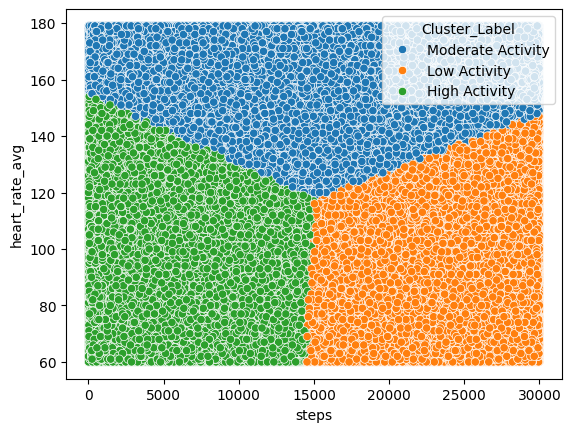

In [32]:
sns.scatterplot(data=df, x='steps', y='heart_rate_avg', hue='Cluster_Label')
plt.show()

In [33]:
df.to_csv("clustered_data.csv", index=False)